B.1. Write Python code to implement a regression model for weather forecasting.
Compare simple regression, Ridge regression, and Lasso regression.

Simple linear regration consists of main 3 functions: 
1. main regration function for prediction
    $
    y = mx + b
    $

2. Error Function 
$E = \frac{1}{m}\sum_{i=0}^{n}{(yi - (mx + b))^2}$

our main goal is to find $\textbf{m}$ and $\textbf{b}$ where the $\textbf{E}$ is minimum

so for the minimum of $\textbf{E}$ 

1. $\frac{\delta{E}}{\delta{m}} = -\frac{2}{n}\sum_{i=0}^{n}{x(yi - (mx + b))}$

2. $\frac{\delta{E}}{\delta{b}} = -\frac{2}{n}\sum_{i=0}^{n}{(yi - {mx + b})}$

$\textbf{simple regression}$

In [34]:
!pip install pandas matplotlib

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [36]:
weather_data = pd.read_csv('/home/rito/ju_lab/Diptadip/weather.csv')
weather_df = pd.DataFrame(weather_data)
print(weather_df)

     MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine WindGustDir  \
0        8.0     24.3       0.0          3.4       6.3          NW   
1       14.0     26.9       3.6          4.4       9.7         ENE   
2       13.7     23.4       3.6          5.8       3.3          NW   
3       13.3     15.5      39.8          7.2       9.1          NW   
4        7.6     16.1       2.8          5.6      10.6         SSE   
..       ...      ...       ...          ...       ...         ...   
361      9.0     30.7       0.0          7.6      12.1         NNW   
362      7.1     28.4       0.0         11.6      12.7           N   
363     12.5     19.9       0.0          8.4       5.3         ESE   
364     12.5     26.9       0.0          5.0       7.1          NW   
365     12.3     30.2       0.0          6.0      12.6          NW   

     WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  ...  Humidity3pm  \
0             30.0         SW         NW           6.0  ...           29   
1      

In [37]:
# Convert to numpy arrays (optional but good practice)
x_data = np.array(weather_df.Evaporation)
y_data = np.array(weather_df.MaxTemp)

# Create random indices for training (2/3 of data)
train_indices = np.random.choice(len(x_data), int(2 * len(x_data) / 3), replace=False)

# Remaining indices for testing
test_indices = np.setdiff1d(np.arange(len(x_data)), train_indices)

# Split data
x_train = x_data[train_indices]
y_train = y_data[train_indices]

x_test = x_data[test_indices]
y_test = y_data[test_indices]


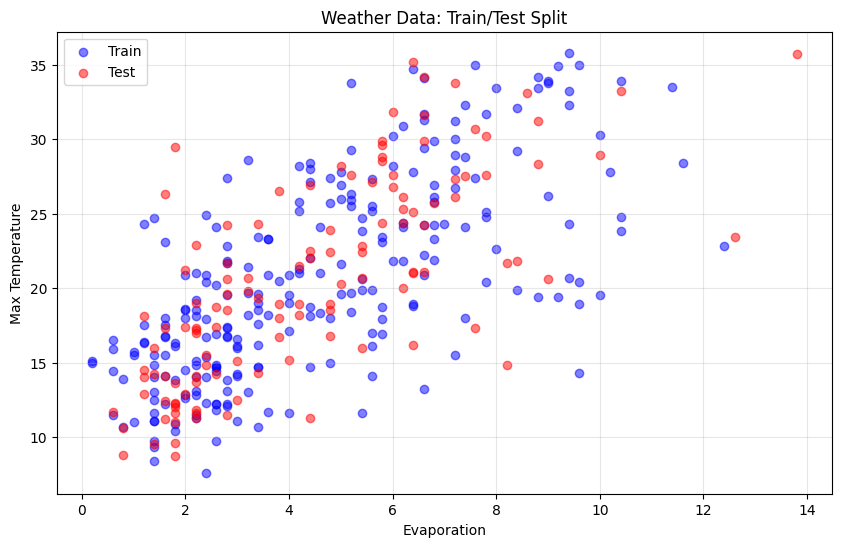

In [69]:
plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color="blue", label='Train', alpha=0.5)
plt.scatter(x_test, y_test, color='red', label='Test', alpha=0.5)
plt.xlabel('Evaporation')
plt.ylabel('Max Temperature')
plt.title('Weather Data: Train/Test Split')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
#error function
def errror_func(m,b,x,y):
    total_error = 0
    for i in range(len(x)):
        total_error += (y - (m*x + b))**2
    total_error / float(len(x))
    return total_error

In [74]:
def gradient_decent(m_now, b_now, x, y, L):
    m_grad = 0
    b_grad = 0

    n = len(x)

    for i in range(n):
        m_grad += -(2/n)*(y[i] - (m_now*x[i] + b_now)) * x[i]
        b_grad += -(2/n)*(y[i] - (m_now*x[i] + b_now))

    m_l = m_now - L * m_grad
    b_l = b_now - L * b_grad
    
    return (m_l,b_l)

In [81]:
m = 0 
b = 0

#have to play with the values below to best results and mostly L as the gradient decent depends on L
L = 0.01
epochs = 5000

for i in range(epochs):
    m, b  = gradient_decent(m,b,x_train,y_train,L)
print(m,b)

1.6719323136001216 12.923918752322306


/tmp/ipykernel_15077/3961429837.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(np.sort(x_test), m*np.sort(x_test) + b, 'r-', label='Predicted',color="black")


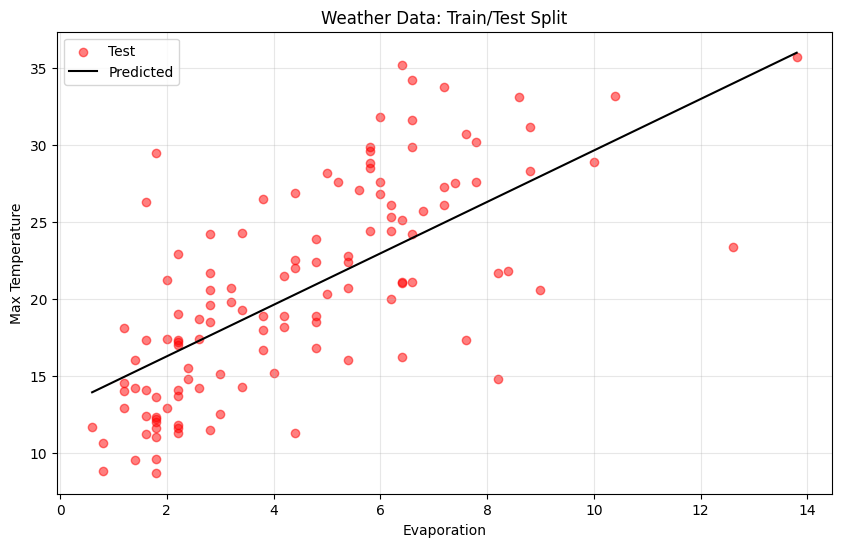

In [100]:
plt.figure(figsize=(10, 6))
# plt.scatter(x_train, y_train, color="blue", label='Train', alpha=0.5)
plt.scatter(x_test, y_test, color='red', label='Test', alpha=0.5)
plt.plot(np.sort(x_test), m*np.sort(x_test) + b, 'r-', label='Predicted',color="black")
plt.xlabel('Evaporation')
plt.ylabel('Max Temperature')
plt.title('Weather Data: Train/Test Split')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

$\textbf{Validation of regration}$

In [82]:
import numpy as np

y_true = np.array(y_test)
y_pred = m * x_test + b

rms = np.sqrt(np.mean((y_pred - y_true) ** 2))
relative_rms = rms / np.mean(y_true) * 100

print(f"RMSE: {rms}")
print(f"Relative RMSE (%): {relative_rms:.2f}%")


RMSE: 4.762606151198432
Relative RMSE (%): 23.18%


$\textbf{Ridge regression}$

The Error Function used in Linear regration is:
$E = \frac{1}{m}\sum_{i=0}^{n}{(yi - (mx + b))^2}$

In Ridge Regression, we add a penalty for large 𝑚 (the weight), called L2 regularization:


$E = \frac{1}{m}\sum_{i=0}^{n}{(yi - (mx + b))^2} + \lambda m^2$

so after the main error function the main objective is still the same as linear regration, so the partical differentiation of error function  with respect to m and b is as following. 
1. $\frac{\delta{E}}{\delta{m}} = -\frac{2}{n}\sum_{i=0}^{n}{x(yi - (mx + b)) + 2\lambda m}$

2. $\frac{\delta{E}}{\delta{b}} = -\frac{2}{n}\sum_{i=0}^{n}{(yi - {mx + b})}$

In [83]:
def gradient_decent_ridge(m_now, b_now, x, y, L,lmda):
    m_grad = 0
    b_grad = 0

    n = len(x)

    for i in range(n):
        m_grad += -(2/n)*(((y[i] - (m_now*x[i] + b_now)) * x[i]) + (2*lmda*m_now))
        b_grad += -(2/n)*(y[i] - (m_now*x[i] + b_now))

    m_l = m_now - L * m_grad
    b_l = b_now - L * b_grad
    
    return (m_l,b_l)

In [84]:
m_r = 0 
b_r = 0

#have to play with the values below to best results and mostly L as the gradient decent depends on L
L = 0.0005
epochs = 5000
lmda = 0.5

for i in range(epochs):
    m_r, b_r  = gradient_decent_ridge(m_r,b_r,x_train,y_train,L,lmda)

print(m_r,b_r)

2.5496992848138302 8.11015392107428


/tmp/ipykernel_15077/3242808172.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(np.sort(x_test), m_r*np.sort(x_test) + b_r, 'r-', label='Predicted',color="black")


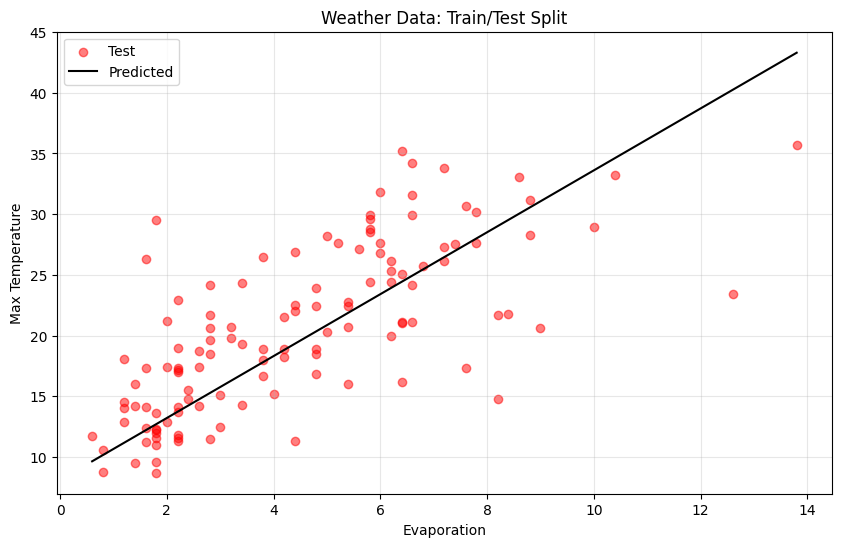

In [101]:
plt.figure(figsize=(10, 6))
# plt.scatter(x_train, y_train, color="blue", label='Train', alpha=0.5)
plt.scatter(x_test, y_test, color='red', label='Test', alpha=0.5)
plt.plot(np.sort(x_test), m_r*np.sort(x_test) + b_r, 'r-', label='Predicted',color="black")
plt.xlabel('Evaporation')
plt.ylabel('Max Temperature')
plt.title('Weather Data: Train/Test Split')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [103]:
import numpy as np

y_true = np.array(y_test)
y_pred = m_r * x_test + b_r

rms = np.sqrt(np.mean((y_pred - y_true) ** 2))
relative_rms = rms / np.mean(y_true) * 100

print(f"RMSE: {rms}")
print(f"Relative RMSE (%): {relative_rms:.2f}%")

RMSE: 5.190021571697508
Relative RMSE (%): 25.27%


$\textbf{Lasso Regression}$

The error function used in ridge regraion was: $E = \frac{1}{m}\sum_{i=0}^{n}{(yi - (mx + b))^2} + \lambda m^2$

In Lasso Regression insted of $m^2$ we use $|m|$ so the new error function is as following

$E = \frac{1}{m}\sum_{i=0}^{n}{(yi - (mx + b))^2} + \lambda |m|$

so after the main error function the main objective is still the same as linear regration, so the partical differentiation of error function  with respect to m and b is as following. 
1. $\frac{\delta{E}}{\delta{m}} = -\frac{2}{n}\sum_{i=0}^{n}{x(yi - (mx + b)) + \lambda \frac{m}{|m|}}$

2. $\frac{\delta{E}}{\delta{b}} = -\frac{2}{n}\sum_{i=0}^{n}{(yi - {mx + b})}$

In [47]:
import math

def gradient_descent_lasso(m_now, b_now, x, y, L, lmda):
    n = len(x)
    m_grad = 0
    b_grad = 0

    # compute gradients from data
    for i in range(n):
        m_grad += -(2/n) * x[i] * (y[i] - (m_now * x[i] + b_now))
        b_grad += -(2/n) * (y[i] - (m_now * x[i] + b_now))

    # add L1 regularization term (not inside the loop)
    m_grad += lmda * math.copysign(1.0, m_now)

    # update parameters
    m_new = m_now - L * m_grad
    b_new = b_now - L * b_grad

    return m_new, b_new


In [93]:
m_L = 0 
b_L = 0

#have to play with the values below to best results and mostly L as the gradient decent depends on L
L = 0.01
epochs = 5000
lmda = 0.005

for i in range(epochs):
    m_L, b_L  = gradient_descent_lasso(m_L,b_L,x_train,y_train,L,lmda)

print(m_L,b_L)

1.6715879925926376 12.925490210822034


/tmp/ipykernel_15077/2117924889.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(np.sort(x_test), m_L*np.sort(x_test) + b_L, 'r-', label='Predicted',color="black")


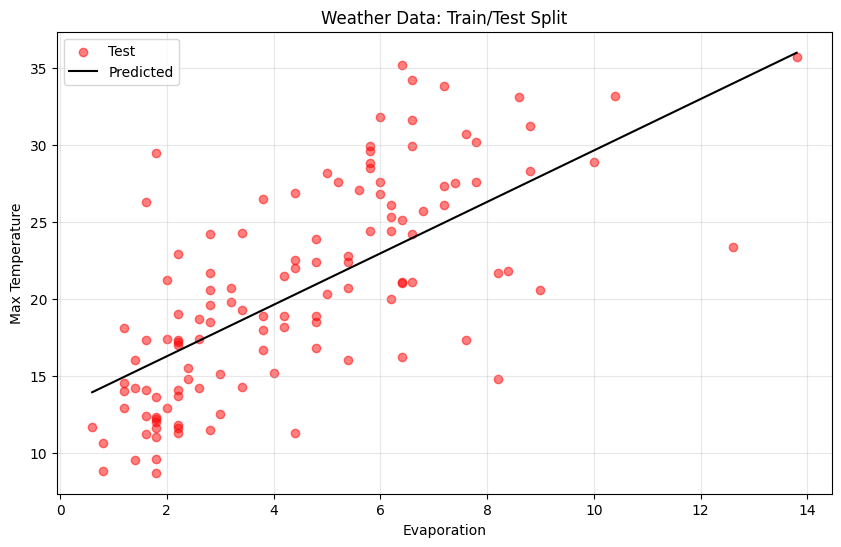

In [102]:
plt.figure(figsize=(10, 6))
# plt.scatter(x_train, y_train, color="blue", label='Train', alpha=0.5)
plt.scatter(x_test, y_test, color='red', label='Test', alpha=0.5)
plt.plot(np.sort(x_test), m_L*np.sort(x_test) + b_L, 'r-', label='Predicted',color="black")
plt.xlabel('Evaporation')
plt.ylabel('Max Temperature')
plt.title('Weather Data: Train/Test Split')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [95]:
import numpy as np

y_true = np.array(y_test)
y_pred = m_L * x_test + b_L

rms = np.sqrt(np.mean((y_pred - y_true) ** 2))
relative_rms = rms / np.mean(y_true) * 100

print(f"RMSE: {rms}")
print(f"Relative RMSE (%): {relative_rms:.2f}%")

RMSE: 4.762694320139463
Relative RMSE (%): 23.19%
